In [18]:
# =====================================================
# Conditional GAN (cGAN) with Pretrained cAE
# Condition = [area_norm (B,1) || label_onehot (B,C)]
# =====================================================

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch.nn.functional as F

# =====================================================
# Paths
# =====================================================
ae_model_path = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelAEV4\cae_fold4.pt")
dataset_path = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\Datasetv3\gcode_layers_V4.npy")
gan_output_dir = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelGANV4")
out_img_dir = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\OutputGANV4")

gan_output_dir.mkdir(parents=True, exist_ok=True)
out_img_dir.mkdir(parents=True, exist_ok=True)

# =====================================================
# Hyperparameters
# =====================================================
latent_size = 512         # must match CAE latent size
point_size = 2030         # from dataset
batch_size = 32
epochs = 2001
lr = 1e-4
device = 'cuda'

# =====================================================
# Load Dataset
# =====================================================
dataset = np.load(dataset_path, allow_pickle=True).item()
points = dataset["data"]            # (N, L, P, 2)
labels = dataset["labels"]          # list of class names
label_map = dataset["label_map"]    # dict {name: int}
areas_norm = dataset["areas_norm"]  # (N, L)

num_classes = len(label_map)
cond_dim = 1 + num_classes   # area + onehot

# Flatten (file,layer) → samples
flat_points = points.reshape(-1, point_size, 2)
flat_labels = np.repeat(np.arange(len(labels)), points.shape[1])  # int labels per file
flat_areas = areas_norm.reshape(-1, 1)

# =====================================================
# Dataset Loader
# =====================================================
class GCodeDataset(Dataset):
    def __init__(self, X, y, a, num_classes):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.a = torch.tensor(a, dtype=torch.float32)
        self.num_classes = num_classes
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        x = self.X[idx]        # (P,2)
        a = self.a[idx]        # (1,)
        y = self.y[idx]        # ()
        y1h = F.one_hot(y, num_classes=self.num_classes).float()  # (C,)
        cond = torch.cat([a, y1h], dim=0)  # (1+C,)
        return x, cond

dataloader = DataLoader(GCodeDataset(flat_points, flat_labels, flat_areas, num_classes),
                        batch_size=batch_size, shuffle=True)

# =====================================================
# Conditional AutoEncoder (matching CAE training)
# =====================================================
class PointCloudCAE(nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        super().__init__()
        self.P = point_size
        self.enc = nn.Sequential(
            nn.Linear(point_size * 2, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, latent_size),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_size + cond_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, point_size * 2),
        )
    def forward(self, x, cond):
        B = x.shape[0]
        x_flat = x.view(B, -1)
        z = self.enc(x_flat)              # (B, latent)
        zc = torch.cat([z, cond], dim=1)  # (B, latent+cond)
        out = self.dec(zc).view(B, self.P, 2)
        return out

# Load pretrained CAE
cae = PointCloudCAE(point_size, latent_size, cond_dim).to(device)
cae.load_state_dict(torch.load(ae_model_path, map_location=device))
cae.eval()

# =====================================================
# Conditional GAN Models
# =====================================================
class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )
    def forward(self, z, cond):
        return self.model(torch.cat([z, cond], dim=1))

class Discriminator(nn.Module):
    def __init__(self, latent_dim, cond_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1), nn.Sigmoid()
        )
    def forward(self, z, cond):
        return self.model(torch.cat([z, cond], dim=1))

G = Generator(latent_size, cond_dim).to(device)
D = Discriminator(latent_size, cond_dim).to(device)

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
loss_fn = nn.BCELoss()

# =====================================================
# Training Loop
# =====================================================
g_losses, d_losses = [], []
for epoch in range(epochs):
    for x, cond in dataloader:
        x, cond = x.to(device), cond.to(device)

        # === Encode real points → latent ===
        with torch.no_grad():
            z_real = cae.enc(x.view(x.size(0), -1))   # (B, latent)

        # === Fake latent ===
        z_noise = torch.randn(x.size(0), latent_size).to(device)
        z_fake = G(z_noise, cond)

        # --- Discriminator ---
        real_valid = torch.ones(x.size(0), 1).to(device)
        fake_valid = torch.zeros(x.size(0), 1).to(device)

        d_real = D(z_real, cond)
        d_fake = D(z_fake.detach(), cond)

        d_loss = loss_fn(d_real, real_valid) + loss_fn(d_fake, fake_valid)
        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # --- Generator ---
        g_fake = D(z_fake, cond)
        g_loss = loss_fn(g_fake, real_valid)
        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())
    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    # Save samples every 100 epochs
    if (epoch+1) % 100 == 0:
        torch.save(G.state_dict(), gan_output_dir / f"cgan_generator_epoch{epoch+1}.pt")
        torch.save(D.state_dict(), gan_output_dir / f"cgan_discriminator_epoch{epoch+1}.pt")

        with torch.no_grad():
            z_noise = torch.randn(num_classes, latent_size).to(device)
            labels_eye = torch.eye(num_classes).to(device)   # onehot
            areas_dummy = torch.rand(num_classes, 1).to(device)  # 🔥 random [0,1] per class
            conds = torch.cat([areas_dummy, labels_eye], dim=1)  # (num_classes, 1+C)
        
            fake_latents = G(z_noise, conds)
            decoded = cae.dec(torch.cat([fake_latents, conds], dim=1)).view(
                num_classes, point_size, 2
            ).cpu().numpy()
        
            fig, axs = plt.subplots(1, num_classes, figsize=(20, 4))
            for i in range(num_classes):
                axs[i].scatter(decoded[i][:, 0], decoded[i][:, 1], s=1)
                axs[i].set_title(f"Class {i} | area={areas_dummy[i].item():.2f}")  # show area
                axs[i].axis("equal")
                axs[i].grid(True)
            plt.tight_layout()
            plt.savefig(out_img_dir / f"epoch_{epoch+1:04d}_samples.png")
            plt.close()
    # === Plot and save losses ===
    plt.figure(figsize=(10,5))
    plt.plot(g_losses, label="Generator Loss")
    plt.plot(d_losses, label="Discriminator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"cGAN Training Loss (up to epoch {epoch+1})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out_img_dir / f"epoch_loss.png")
    plt.close()
# =====================================================
# Final Save
# =====================================================
torch.save(G.state_dict(), gan_output_dir / "cgan_generator_final.pt")
torch.save(D.state_dict(), gan_output_dir / "cgan_discriminator_final.pt")

plt.figure(figsize=(10,5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("cGAN Training Loss")
plt.legend(); plt.grid(True)
plt.savefig(gan_output_dir / "final_loss_plot.png")
plt.close()

print("✅ cGAN Training Complete.")


Epoch 1/2001 | D Loss: 1.3669 | G Loss: 0.7274
Epoch 2/2001 | D Loss: 1.3683 | G Loss: 0.7159
Epoch 3/2001 | D Loss: 1.3657 | G Loss: 0.7087
Epoch 4/2001 | D Loss: 1.3647 | G Loss: 0.7102


KeyboardInterrupt: 

Epoch 1/4001 | D Loss: 4.0558 | G Loss: -0.4803
Epoch 2/4001 | D Loss: 2.8045 | G Loss: -2.3590
Epoch 3/4001 | D Loss: 1.5498 | G Loss: -1.0900
Epoch 4/4001 | D Loss: -2.6250 | G Loss: 2.9389
Epoch 5/4001 | D Loss: -4.6572 | G Loss: 5.1242
Epoch 6/4001 | D Loss: -4.0006 | G Loss: 4.3324
Epoch 7/4001 | D Loss: -4.3679 | G Loss: 4.7165
Epoch 8/4001 | D Loss: -5.7835 | G Loss: 6.4624
Epoch 9/4001 | D Loss: -6.1149 | G Loss: 7.1638
Epoch 10/4001 | D Loss: -6.1770 | G Loss: 7.4120
Epoch 11/4001 | D Loss: -6.0170 | G Loss: 7.3382
Epoch 12/4001 | D Loss: -5.9909 | G Loss: 7.3459
Epoch 13/4001 | D Loss: -5.9131 | G Loss: 7.4209
Epoch 14/4001 | D Loss: -5.9275 | G Loss: 7.2750
Epoch 15/4001 | D Loss: -6.0791 | G Loss: 7.4122
Epoch 16/4001 | D Loss: -5.9005 | G Loss: 7.1679
Epoch 17/4001 | D Loss: -5.7669 | G Loss: 6.9387
Epoch 18/4001 | D Loss: -5.7522 | G Loss: 6.9149
Epoch 19/4001 | D Loss: -5.6022 | G Loss: 6.7315
Epoch 20/4001 | D Loss: -5.6400 | G Loss: 6.7360
Epoch 21/4001 | D Loss: -5.51

KeyboardInterrupt: 

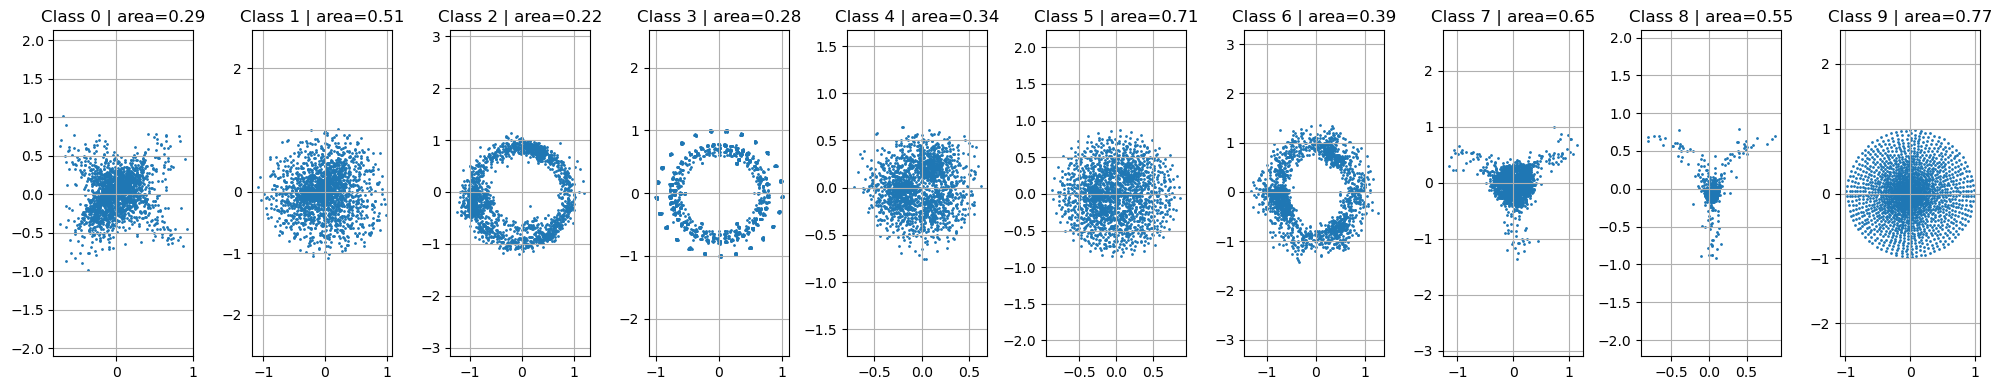

In [29]:
# =====================================================
# C-WGAN-GP (Conditional) with Pretrained cAE
# =====================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# =====================================================
# Paths
# =====================================================
ae_model_path = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelAEV4\cae_fold4.pt")
dataset_path = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\Datasetv3\gcode_layers_V4.npy")
gan_output_dir = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelGANV4_WGANGP")
out_img_dir = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\OutputGANV4_WGANGP")

gan_output_dir.mkdir(parents=True, exist_ok=True)
out_img_dir.mkdir(parents=True, exist_ok=True)

# =====================================================
# Hyperparameters
# =====================================================
latent_size = 512
point_size = 2030
batch_size = 32
epochs = 4001
lr = 5e-5
n_critic = 5
lambda_gp = 10   # gradient penalty coefficient
device = 'cuda'

# =====================================================
# Load Dataset
# =====================================================
dataset = np.load(dataset_path, allow_pickle=True).item()
points = dataset["data"]
labels = dataset["labels"]
label_map = dataset["label_map"]
areas_norm = dataset["areas_norm"]

num_classes = len(label_map)
cond_dim = 1 + num_classes

flat_points = points.reshape(-1, point_size, 2)
flat_labels = np.repeat(np.arange(len(labels)), points.shape[1])
flat_areas = areas_norm.reshape(-1, 1)

class GCodeDataset(Dataset):
    def __init__(self, X, y, a, num_classes):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.a = torch.tensor(a, dtype=torch.float32)
        self.num_classes = num_classes
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        x = self.X[idx]
        a = self.a[idx]
        y = self.y[idx]
        y1h = F.one_hot(y, num_classes=self.num_classes).float()
        cond = torch.cat([a, y1h], dim=0)
        return x, cond

dataloader = DataLoader(GCodeDataset(flat_points, flat_labels, flat_areas, num_classes),
                        batch_size=batch_size, shuffle=True)

# =====================================================
# Conditional AutoEncoder
# =====================================================
class PointCloudCAE(nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        super().__init__()
        self.P = point_size
        self.enc = nn.Sequential(
            nn.Linear(point_size * 2, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, latent_size),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_size + cond_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, point_size * 2),
        )
    def forward(self, x, cond):
        B = x.shape[0]
        x_flat = x.view(B, -1)
        z = self.enc(x_flat)
        zc = torch.cat([z, cond], dim=1)
        out = self.dec(zc).view(B, self.P, 2)
        return out

cae = PointCloudCAE(point_size, latent_size, cond_dim).to(device)
cae.load_state_dict(torch.load(ae_model_path, map_location=device))
cae.eval()

# =====================================================
# Networks (Balanced for WGAN-GP)
# =====================================================
class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 256),
            nn.BatchNorm1d(256), nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024), nn.LeakyReLU(0.2),

            nn.Linear(1024, latent_dim)   # latent vector output
        )
    def forward(self, z, cond):
        return self.model(torch.cat([z, cond], dim=1))
        
class Critic(nn.Module):
    def __init__(self, latent_dim, cond_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1)   # no sigmoid for WGAN
        )
    def forward(self, z, cond):
        return self.model(torch.cat([z, cond], dim=1))

G = Generator(latent_size, cond_dim).to(device)
D = Critic(latent_size, cond_dim).to(device)

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.0, 0.9))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.0, 0.9))

# =====================================================
# Gradient Penalty Function
# =====================================================
def compute_gradient_penalty(D, real_samples, fake_samples, cond):
    alpha = torch.rand(real_samples.size(0), 1).to(device)
    alpha = alpha.expand_as(real_samples)

    interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)
    d_interpolates = D(interpolates, cond)

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(gradients.size(0), -1)
    gradient_norm = gradients.norm(2, dim=1)
    gp = lambda_gp * ((gradient_norm - 1) ** 2).mean()
    return gp

# =====================================================
# Training Loop (WGAN-GP)
# =====================================================
g_losses, d_losses = [], []
for epoch in range(epochs):
    for i, (x, cond) in enumerate(dataloader):
        x, cond = x.to(device), cond.to(device)

        # --- Real latent from CAE ---
        with torch.no_grad():
            z_real = cae.enc(x.view(x.size(0), -1))

        # --- Fake latent ---
        z_noise = torch.randn(x.size(0), latent_size).to(device)
        z_fake = G(z_noise, cond)

        # --- Critic Update ---
        d_real = D(z_real, cond)
        d_fake = D(z_fake.detach(), cond)
        gp = compute_gradient_penalty(D, z_real.data, z_fake.data, cond)

        d_loss = -(torch.mean(d_real) - torch.mean(d_fake)) + gp

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # --- Generator Update (every n_critic steps) ---
        if i % n_critic == 0:
            g_fake = D(z_fake, cond)
            g_loss = -torch.mean(g_fake)

            opt_G.zero_grad()
            g_loss.backward()
            opt_G.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())
    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    # Save and visualize every 100 epochs
    if (epoch+1) % 500 == 0:
        torch.save(G.state_dict(), gan_output_dir / f"wgangp_generator_epoch{epoch+1}.pt")
        torch.save(D.state_dict(), gan_output_dir / f"wgangp_critic_epoch{epoch+1}.pt")
    if (epoch+1) % 25 == 0:
        with torch.no_grad():
            z_noise = torch.randn(num_classes, latent_size).to(device)
            labels_eye = torch.eye(num_classes).to(device)
            areas_dummy = torch.rand(num_classes, 1).to(device)
            conds = torch.cat([areas_dummy, labels_eye], dim=1)

            fake_latents = G(z_noise, conds)
            decoded = cae.dec(torch.cat([fake_latents, conds], dim=1)).view(
                num_classes, point_size, 2
            ).cpu().numpy()

            fig, axs = plt.subplots(1, num_classes, figsize=(20, 4))
            for i in range(num_classes):
                axs[i].scatter(decoded[i][:, 0], decoded[i][:, 1], s=1)
                axs[i].set_title(f"Class {i} | area={areas_dummy[i].item():.2f}")
                axs[i].axis("equal")
                axs[i].grid(True)
            plt.tight_layout()
            plt.savefig(out_img_dir / f"epoch_{epoch+1:04d}_samples.png")
            plt.close()

    # === Save loss curve each epoch ===
    plt.figure(figsize=(10,5))
    plt.plot(g_losses, label="Generator Loss")
    plt.plot(d_losses, label="Critic Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"C-WGAN-GP Training Loss (up to epoch {epoch+1})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out_img_dir / f"epoch_loss.png")
    plt.close()

# Final save
torch.save(G.state_dict(), gan_output_dir / "wgangp_generator_final.pt")
torch.save(D.state_dict(), gan_output_dir / "wgangp_critic_final.pt")


In [7]:
# =====================================================
# C-WGAN-GP + Gaussian Penalty (Conditional) with Pretrained cAE
# =====================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# =====================================================
# Paths
# =====================================================
ae_model_path = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelAEV4\cae_fold4.pt")
dataset_path = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\Datasetv3\gcode_layers_V4.npy")
gan_output_dir = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelGANV4_WGANGP_Gauss")
out_img_dir = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\OutputGANV4_WGANGP_Gauss")

gan_output_dir.mkdir(parents=True, exist_ok=True)
out_img_dir.mkdir(parents=True, exist_ok=True)

# =====================================================
# Hyperparameters
# =====================================================
latent_size = 512
point_size = 2030
batch_size = 32
epochs = 4001
lr = 3e-5
n_critic = 5
lambda_gp = 10       # gradient penalty coefficient
lambda_gauss = 0.1   # gaussian penalty coefficient
sigma_gauss = 0.05   # gaussian noise std for penalty
device = 'cuda'

# =====================================================
# Load Dataset
# =====================================================
dataset = np.load(dataset_path, allow_pickle=True).item()
points = dataset["data"]
labels = dataset["labels"]
label_map = dataset["label_map"]
areas_norm = dataset["areas_norm"]

num_classes = len(label_map)
cond_dim = 1 + num_classes

flat_points = points.reshape(-1, point_size, 2)
flat_labels = np.repeat(np.arange(len(labels)), points.shape[1])
flat_areas = areas_norm.reshape(-1, 1)

class GCodeDataset(Dataset):
    def __init__(self, X, y, a, num_classes):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.a = torch.tensor(a, dtype=torch.float32)
        self.num_classes = num_classes
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        x = self.X[idx]
        a = self.a[idx]
        y = self.y[idx]
        y1h = F.one_hot(y, num_classes=self.num_classes).float()
        cond = torch.cat([a, y1h], dim=0)
        return x, cond

dataloader = DataLoader(GCodeDataset(flat_points, flat_labels, flat_areas, num_classes),
                        batch_size=batch_size, shuffle=True)

# =====================================================
# Conditional AutoEncoder (Pretrained)
# =====================================================
class PointCloudCAE(nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        super().__init__()
        self.P = point_size
        self.enc = nn.Sequential(
            nn.Linear(point_size * 2, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, latent_size),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_size + cond_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, point_size * 2),
        )
    def forward(self, x, cond):
        B = x.shape[0]
        x_flat = x.view(B, -1)
        z = self.enc(x_flat)
        zc = torch.cat([z, cond], dim=1)
        out = self.dec(zc).view(B, self.P, 2)
        return out

cae = PointCloudCAE(point_size, latent_size, cond_dim).to(device)
cae.load_state_dict(torch.load(ae_model_path, map_location=device))
cae.eval()

# =====================================================
# Generator + Critic
#note1: (g512-1024 works good with c1024-256 )
# =====================================================
class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024), nn.LeakyReLU(0.2),

            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048), nn.LeakyReLU(0.2),
            
            nn.Linear(2048, latent_dim)   # latent vector output
        )
    def forward(self, z, cond):
        return self.model(torch.cat([z, cond], dim=1))
        
class Critic(nn.Module):
    def __init__(self, latent_dim, cond_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 2048),
            nn.LeakyReLU(0.2),

            nn.Linear(2048, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1)   # no sigmoid for WGAN
        )
    def forward(self, z, cond):
        return self.model(torch.cat([z, cond], dim=1))

G = Generator(latent_size, cond_dim).to(device)
D = Critic(latent_size, cond_dim).to(device)

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.0, 0.9))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.0, 0.9))

# =====================================================
# Regularization Functions
# =====================================================
def compute_gradient_penalty(D, real_samples, fake_samples, cond):
    alpha = torch.rand(real_samples.size(0), 1).to(device)
    alpha = alpha.expand_as(real_samples)

    interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)
    d_interpolates = D(interpolates, cond)

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(gradients.size(0), -1)
    gradient_norm = gradients.norm(2, dim=1)
    gp = lambda_gp * ((gradient_norm - 1) ** 2).mean()
    return gp

def compute_gaussian_penalty(D, real_samples, fake_samples, cond, sigma=0.05):
    noise_real = real_samples + sigma * torch.randn_like(real_samples)
    noise_fake = fake_samples + sigma * torch.randn_like(fake_samples)
    d_real_noisy = D(noise_real, cond)
    d_fake_noisy = D(noise_fake, cond)
    penalty = 0.5 * (d_real_noisy ** 2).mean() + 0.5 * (d_fake_noisy ** 2).mean()
    return penalty

# =====================================================
# Training Loop
# =====================================================
g_losses, d_losses = [], []
for epoch in range(epochs):
    for i, (x, cond) in enumerate(dataloader):
        x, cond = x.to(device), cond.to(device)

        # --- Real latent from CAE ---
        with torch.no_grad():
            z_real = cae.enc(x.view(x.size(0), -1))

        # --- Fake latent ---
        z_noise = torch.randn(x.size(0), latent_size).to(device)
        z_fake = G(z_noise, cond)

        # --- Critic Update ---
        d_real = D(z_real, cond)
        d_fake = D(z_fake.detach(), cond)
        gp = compute_gradient_penalty(D, z_real.data, z_fake.data, cond)
        gauss_pen = compute_gaussian_penalty(D, z_real.data, z_fake.data, cond, sigma_gauss)

        d_loss = -(torch.mean(d_real) - torch.mean(d_fake)) + gp + lambda_gauss * gauss_pen

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # --- Generator Update (every n_critic steps) ---
        if i % n_critic == 0:
            g_fake = D(z_fake, cond)
            g_loss = -torch.mean(g_fake)

            opt_G.zero_grad()
            g_loss.backward()
            opt_G.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())
    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    # Save and visualize every 100 epochs
    if (epoch+1) % 500 == 0:
        torch.save(G.state_dict(), gan_output_dir / f"wgangp_gauss_generator_epoch{epoch+1}.pt")
        torch.save(D.state_dict(), gan_output_dir / f"wgangp_gauss_critic_epoch{epoch+1}.pt")
    if (epoch+1) % 25 == 0:
        with torch.no_grad():
            z_noise = torch.randn(num_classes, latent_size).to(device)
            labels_eye = torch.eye(num_classes).to(device)
            areas_dummy = torch.rand(num_classes, 1).to(device)
            conds = torch.cat([areas_dummy, labels_eye], dim=1)

            fake_latents = G(z_noise, conds)
            decoded = cae.dec(torch.cat([fake_latents, conds], dim=1)).view(
                num_classes, point_size, 2
            ).cpu().numpy()

            fig, axs = plt.subplots(1, num_classes, figsize=(20, 4))
            for i in range(num_classes):
                axs[i].scatter(decoded[i][:, 0], decoded[i][:, 1], s=1)
                axs[i].set_title(f"Class {i} | area={areas_dummy[i].item():.2f}")
                axs[i].axis("equal")
                axs[i].grid(True)
            plt.tight_layout()
            plt.savefig(out_img_dir / f"epoch_{epoch+1:04d}_samples.png")
            plt.close()

    # === Save loss curve each epoch ===
    plt.figure(figsize=(10,5))
    plt.plot(g_losses, label="Generator Loss")
    plt.plot(d_losses, label="Critic Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"C-WGAN-GP+Gaussian Training Loss (up to epoch {epoch+1})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out_img_dir /"img"/ f"epoch_{epoch+1:04d}_loss.png")
    plt.close()

# Final save
torch.save(G.state_dict(), gan_output_dir / "wgangp_gauss_generator_final.pt")
torch.save(D.state_dict(), gan_output_dir / "wgangp_gauss_critic_final.pt")


Epoch 1/4001 | D Loss: 5.9423 | G Loss: -0.3597
Epoch 2/4001 | D Loss: 3.6649 | G Loss: -2.2852
Epoch 3/4001 | D Loss: 1.6037 | G Loss: -0.4664
Epoch 4/4001 | D Loss: -2.8140 | G Loss: 3.8709
Epoch 5/4001 | D Loss: -3.6283 | G Loss: 5.1507
Epoch 6/4001 | D Loss: -3.7159 | G Loss: 5.1146
Epoch 7/4001 | D Loss: -4.2109 | G Loss: 5.6516
Epoch 8/4001 | D Loss: -4.3941 | G Loss: 5.2843
Epoch 9/4001 | D Loss: -4.6901 | G Loss: 4.7528
Epoch 10/4001 | D Loss: -4.6257 | G Loss: 4.0868
Epoch 11/4001 | D Loss: -4.7857 | G Loss: 4.2246
Epoch 12/4001 | D Loss: -4.7652 | G Loss: 3.8900
Epoch 13/4001 | D Loss: -4.8126 | G Loss: 3.6662
Epoch 14/4001 | D Loss: -4.8298 | G Loss: 3.8090
Epoch 15/4001 | D Loss: -4.8583 | G Loss: 3.5686
Epoch 16/4001 | D Loss: -4.8218 | G Loss: 3.2930
Epoch 17/4001 | D Loss: -4.8633 | G Loss: 3.2774
Epoch 18/4001 | D Loss: -4.8049 | G Loss: 3.0345
Epoch 19/4001 | D Loss: -4.8403 | G Loss: 3.3058
Epoch 20/4001 | D Loss: -4.8722 | G Loss: 3.1284
Epoch 21/4001 | D Loss: -4.83

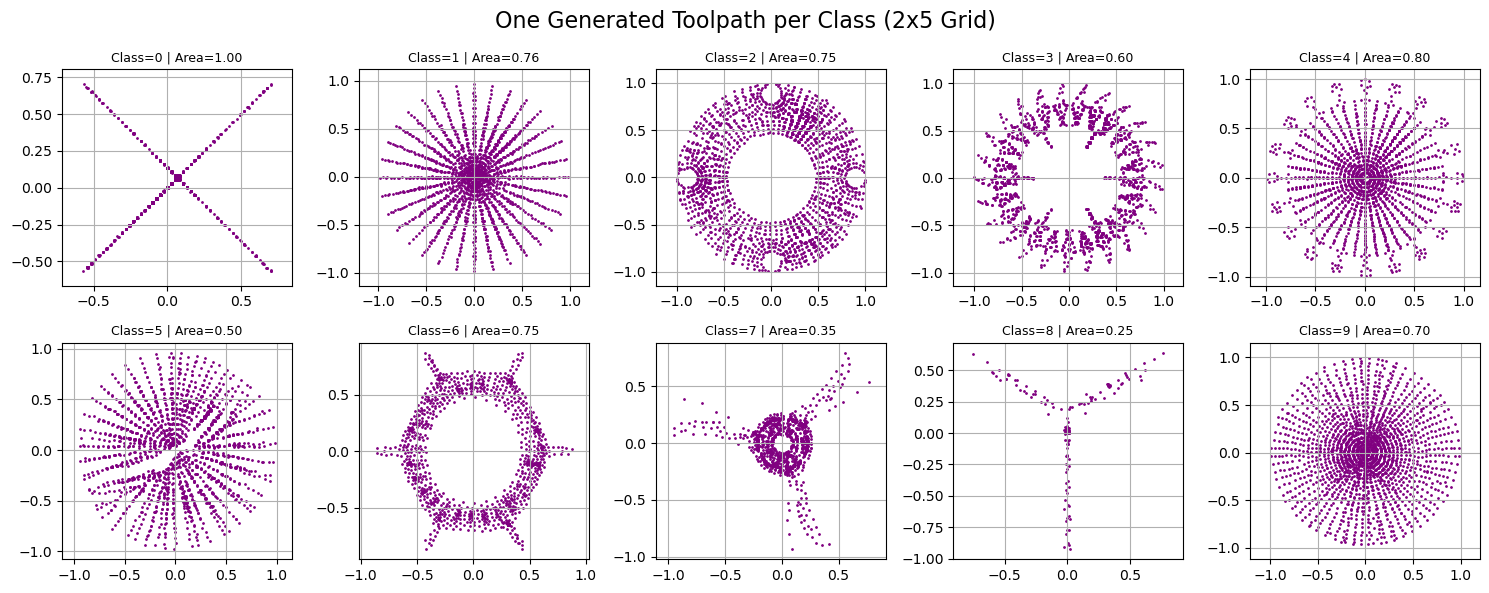

In [24]:
# =====================================================
# Inference: C-WGAN-GP + Gaussian Penalty (Conditional)
# One Sample per Class (2x5 Grid)
# =====================================================

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# =====================================================
# Paths
# =====================================================
gan_model_path = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelGANV4_WGANGP_Gauss\wgangp_gauss_generator_final.pt")
ae_model_path  = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelAEV4\cae_fold5.pt")

# =====================================================
# Hyperparameters (must match training)
# =====================================================
latent_size = 512
point_size = 2030        # number of 2D points per layer (adjust if different)
num_classes = 10         # adjust to your label_map size
cond_dim = 1 + num_classes
device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# Models
# =====================================================
class PointCloudCAE(nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        super().__init__()
        self.P = point_size
        self.enc = nn.Sequential(
            nn.Linear(point_size * 2, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, latent_size),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_size + cond_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, point_size * 2),
        )
    def forward(self, z, cond):
        zc = torch.cat([z, cond], dim=1)
        out = self.dec(zc).view(-1, self.P, 2)
        return out

class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048), nn.LeakyReLU(0.2),
            nn.Linear(2048, latent_dim)
        )
    def forward(self, z, cond):
        return self.model(torch.cat([z, cond], dim=1))

# =====================================================
# Load Models
# =====================================================
cae = PointCloudCAE(point_size, latent_size, cond_dim).to(device)
cae.load_state_dict(torch.load(ae_model_path, map_location=device))
cae.eval()

G = Generator(latent_size, cond_dim).to(device)
G.load_state_dict(torch.load(gan_model_path, map_location=device))
G.eval()

# =====================================================
# Generate One Sample per Class
# =====================================================
with torch.no_grad():
    # Latent noise, one per class
    z_noise = torch.randn(num_classes, latent_size).to(device)

    # Labels = [0 .. num_classes-1]
    labels = torch.arange(num_classes)
    labels_onehot = F.one_hot(labels, num_classes=num_classes).float().to(device)

    # Random areas in [0,1] for each class
    areas_dummy = torch.rand(num_classes, 1).to(device)
    # Python list of your desired areas (length = num_classes)
    areas_list = [1, 0.76, 0.75, 0.6, 0.8, 0.5, 0.75, 0.35, 0.25, 0.7]  
    areas_dummy = torch.tensor(areas_list, dtype=torch.float32).view(num_classes, 1).to(device)

    # Conditions
    conds = torch.cat([areas_dummy, labels_onehot], dim=1)

    # Generator -> latent
    fake_latents = G(z_noise, conds)

    # Decode -> 2D points
    decoded = cae(fake_latents, conds).cpu().numpy()

# =====================================================
# Plot Results (2x5 grid)
# =====================================================
rows, cols = 2, 5
fig, axs = plt.subplots(rows, cols, figsize=(15, 6))

for i in range(num_classes):
    r, c = divmod(i, cols)
    axs[r, c].scatter(decoded[i][:, 0], decoded[i][:, 1], s=1, color="purple")
    axs[r, c].set_title(f"Class={i} | Area={areas_dummy[i].item():.2f}", fontsize=9)
    axs[r, c].axis("equal")
    axs[r, c].grid(True)

plt.suptitle("One Generated Toolpath per Class (2x5 Grid)", fontsize=16)
plt.tight_layout()
plt.show()


In [2]:
# =====================================================
# Compute Min, Max, Mean of Normalized Areas Per Class
# =====================================================

import numpy as np
from pathlib import Path

# Path to dataset
dataset_path = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\Datasetv3\gcode_layers_V4.npy")

# Load dataset
dataset = np.load(dataset_path, allow_pickle=True).item()

areas_norm = np.array(dataset["areas_norm"])   # shape (10, 99)
labels = dataset["labels"]                     # list of class names
label_map = dataset["label_map"]               # dict {class_name: class_id}

print("=== Normalized Area Statistics Per Class ===")
print(f"{'Class ID':<8} {'Label':<12} {'Min':<10} {'Max':<10} {'Mean':<10}")

for class_name, class_id in label_map.items():
    class_areas = areas_norm[class_id, :]  # all areas for this class
    
    min_val = float(np.min(class_areas))
    max_val = float(np.max(class_areas))
    mean_val = float(np.mean(class_areas))
    
    print(f"{class_id:<8} {class_name:<12} {min_val:<10.4f} {max_val:<10.4f} {mean_val:<10.4f}")


=== Normalized Area Statistics Per Class ===
Class ID Label        Min        Max        Mean      
0        cube         1.0000     1.0000     1.0000    
1        cylinder     0.7803     0.7803     0.7803    
2        flange       0.3524     0.7848     0.4662    
3        gear_bevel   0.1753     0.7827     0.6286    
4        gear_spur    0.7791     0.7791     0.7791    
5        lead_screw   0.3199     0.5925     0.5667    
6        nut          0.6892     0.7476     0.7454    
7        propeller    0.0305     0.4344     0.2515    
8        pyramid      0.0000     0.4759     0.1550    
9        sphere       0.0147     0.7850     0.5248    


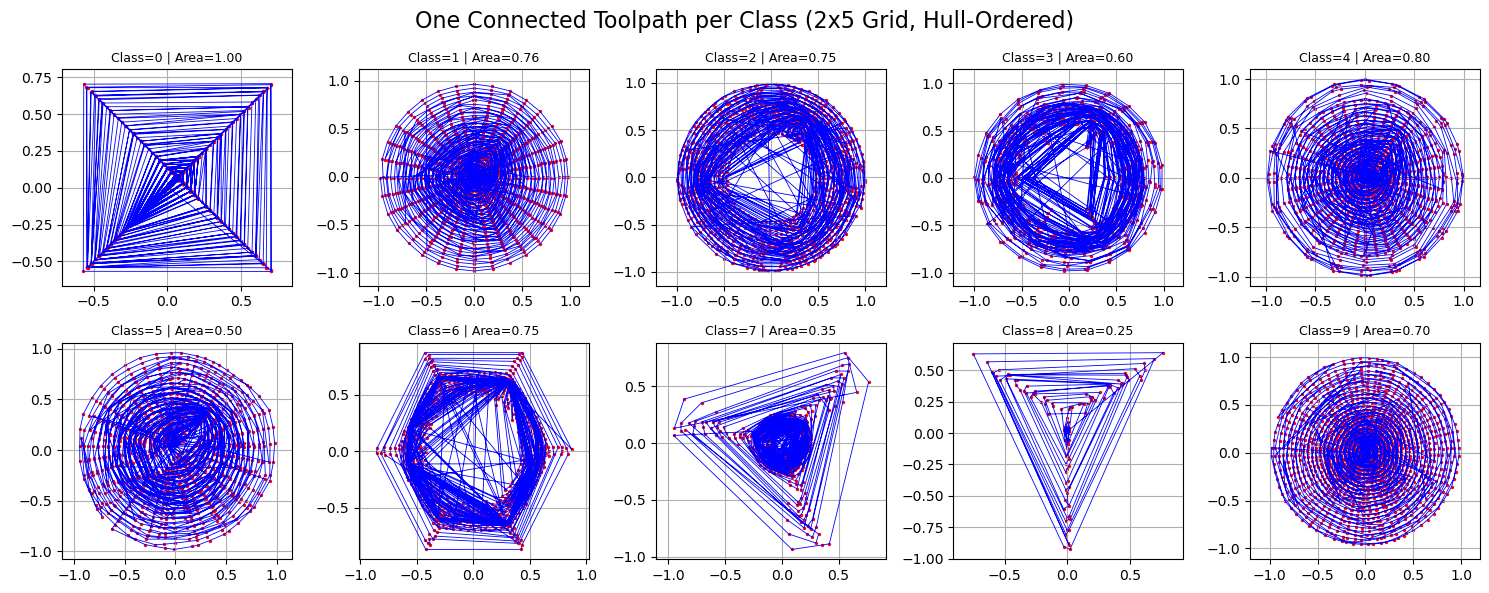

In [5]:
# =====================================================
# Inference: C-WGAN-GP + Gaussian Penalty (Conditional)
# One Sample per Class (2x5 Grid) with Connected Toolpaths
# =====================================================

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from scipy.spatial import ConvexHull

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# =====================================================
# Paths
# =====================================================
gan_model_path = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelGANV4_WGANGP_Gauss\wgangp_gauss_generator_final.pt")
ae_model_path  = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelAEV4\cae_fold5.pt")

# =====================================================
# Hyperparameters (must match training)
# =====================================================
latent_size = 512
point_size = 2030        # number of 2D points per layer (adjust if different)
num_classes = 10
cond_dim = 1 + num_classes
device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# Models
# =====================================================
class PointCloudCAE(nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        super().__init__()
        self.P = point_size
        self.enc = nn.Sequential(
            nn.Linear(point_size * 2, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, latent_size),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_size + cond_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, point_size * 2),
        )
    def forward(self, z, cond):
        zc = torch.cat([z, cond], dim=1)
        out = self.dec(zc).view(-1, self.P, 2)
        return out

class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048), nn.LeakyReLU(0.2),
            nn.Linear(2048, latent_dim)
        )
    def forward(self, z, cond):
        return self.model(torch.cat([z, cond], dim=1))

# =====================================================
# Load Models
# =====================================================
cae = PointCloudCAE(point_size, latent_size, cond_dim).to(device)
cae.load_state_dict(torch.load(ae_model_path, map_location=device))
cae.eval()

G = Generator(latent_size, cond_dim).to(device)
G.load_state_dict(torch.load(gan_model_path, map_location=device))
G.eval()

# =====================================================
# Convex Hull Layered Ordering (onion peeling)
# =====================================================
def layered_hull_path(points):
    """Order points layer-by-layer using convex hulls."""
    pts = points.copy()
    ordered = []
    while len(pts) >= 3:
        try:
            hull = ConvexHull(pts)
            hull_points = pts[hull.vertices]
            ordered.extend(hull_points.tolist())
            mask = np.ones(len(pts), dtype=bool)
            mask[hull.vertices] = False
            pts = pts[mask]
        except:
            break
    if len(pts) > 0:
        ordered.extend(pts.tolist())
    return np.array(ordered)

# =====================================================
# Generate One Sample per Class
# =====================================================
with torch.no_grad():
    z_noise = torch.randn(num_classes, latent_size).to(device)
    labels = torch.arange(num_classes)
    labels_onehot = F.one_hot(labels, num_classes=num_classes).float().to(device)

    # Mean areas from your table
    areas_list = [1, 0.76, 0.75, 0.6, 0.8, 0.5, 0.75, 0.35, 0.25, 0.7]  
    areas_dummy = torch.tensor(areas_list, dtype=torch.float32).view(num_classes, 1).to(device)

    conds = torch.cat([areas_dummy, labels_onehot], dim=1)
    fake_latents = G(z_noise, conds)
    decoded = cae(fake_latents, conds).cpu().numpy()

# =====================================================
# Plot Results (2x5 grid with connected toolpaths)
# =====================================================
rows, cols = 2, 5
fig, axs = plt.subplots(rows, cols, figsize=(15, 6))

for i in range(num_classes):
    r, c = divmod(i, cols)

    # Remove duplicates
    pts = np.unique(np.round(decoded[i], 6), axis=0)

    # Order points via layered convex hulls
    path = layered_hull_path(pts)
    if len(path) > 2:
        path = np.vstack([path, path[0]])

    # Plot path
    axs[r, c].plot(path[:, 0], path[:, 1], '-', color="blue", lw=0.6)
    axs[r, c].scatter(pts[:, 0], pts[:, 1], s=2, color="red")  # optional: show points
    axs[r, c].set_title(f"Class={i} | Area={areas_list[i]:.2f}", fontsize=9)
    axs[r, c].axis("equal")
    axs[r, c].grid(True)

plt.suptitle("One Connected Toolpath per Class (2x5 Grid, Hull-Ordered)", fontsize=16)
plt.tight_layout()
plt.show()


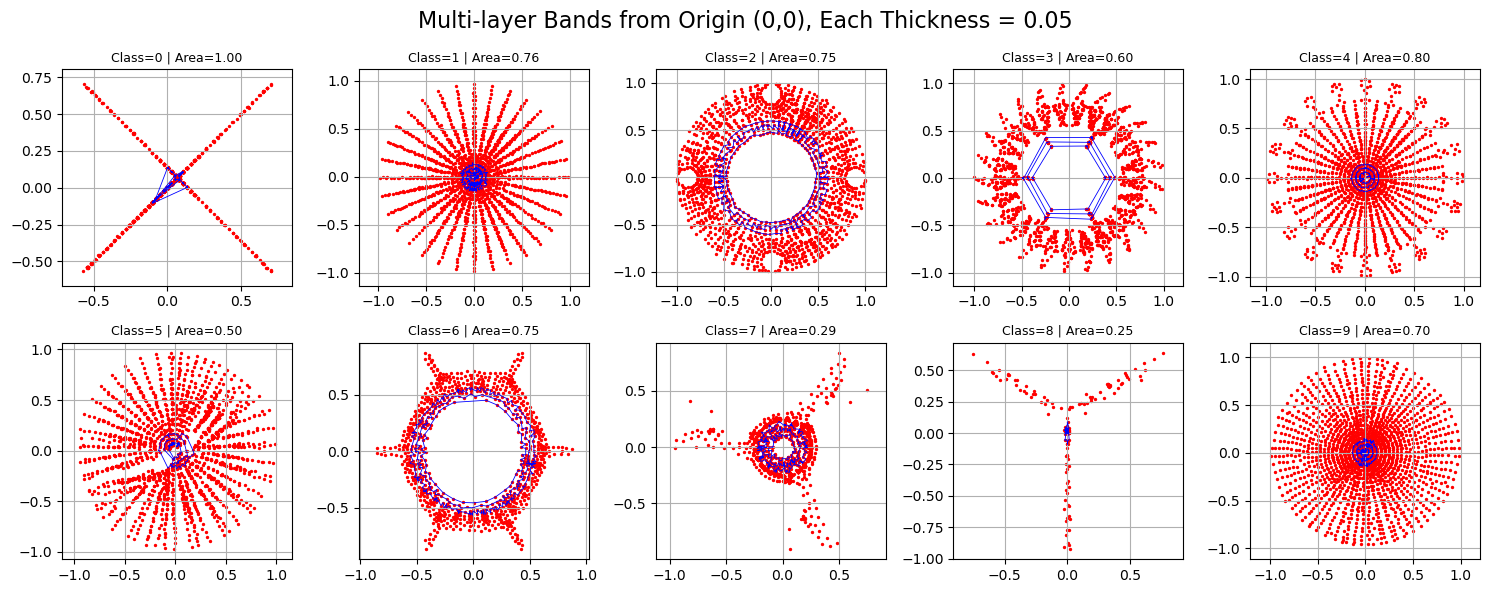

In [49]:
# =====================================================
# Inference: C-WGAN-GP (Conditional)
# One Sample per Class (2x5 Grid) 
# Multi-layer Bands from Origin (0,0), each thickness = 0.05
# =====================================================

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# =====================================================
# Paths
# =====================================================
gan_model_path = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelGANV4_WGANGP_Gauss\wgangp_gauss_generator_final.pt")
ae_model_path  = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelAEV4\cae_fold5.pt")

# =====================================================
# Hyperparameters
# =====================================================
latent_size = 512
point_size = 2030
num_classes = 10
cond_dim = 1 + num_classes
device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# Models
# =====================================================
class PointCloudCAE(nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        super().__init__()
        self.P = point_size
        self.enc = nn.Sequential(
            nn.Linear(point_size * 2, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, latent_size),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_size + cond_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, point_size * 2),
        )
    def forward(self, z, cond):
        zc = torch.cat([z, cond], dim=1)
        out = self.dec(zc).view(-1, self.P, 2)
        return out

class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048), nn.LeakyReLU(0.2),
            nn.Linear(2048, latent_dim)
        )
    def forward(self, z, cond):
        return self.model(torch.cat([z, cond], dim=1))

# =====================================================
# Load Models
# =====================================================
cae = PointCloudCAE(point_size, latent_size, cond_dim).to(device)
cae.load_state_dict(torch.load(ae_model_path, map_location=device))
cae.eval()

G = Generator(latent_size, cond_dim).to(device)
G.load_state_dict(torch.load(gan_model_path, map_location=device))
G.eval()

# =====================================================
# Function: Multi-layer Bands from Origin
# =====================================================
def multilayer_bands_origin(points, band_width=0.05, max_layers=3):
    """
    Build multiple circular layers from origin.
    - r1 = closest distance from origin
    - Layer k = [r1 + (k-1)*band_width, r1 + k*band_width]
    - Continue until no points left or max_layers reached
    """
    dists = np.sqrt(points[:,0]**2 + points[:,1]**2)
    r1 = dists.min()

    loops = []
    for k in range(max_layers):
        low = r1 + k*band_width
        high = r1 + (k+1)*band_width

        band_points = points[(dists >= low) & (dists <= high)]

        if len(band_points) > 3:
            angles = np.arctan2(band_points[:,1], band_points[:,0])
            order = np.argsort(angles)
            loop = band_points[order]
            loop = np.vstack([loop, loop[0]])
            loops.append(loop)

    return loops, points

# =====================================================
# Generate One Sample per Class
# =====================================================
with torch.no_grad():
    z_noise = torch.randn(num_classes, latent_size).to(device)
    labels = torch.arange(num_classes)
    labels_onehot = F.one_hot(labels, num_classes=num_classes).float().to(device)

    # Mean areas (your values)
    areas_list = [1, 0.76, 0.75, 0.6, 0.8, 0.5, 0.75, 0.29, 0.25, 0.7]  
    areas_dummy = torch.tensor(areas_list, dtype=torch.float32).view(num_classes, 1).to(device)

    conds = torch.cat([areas_dummy, labels_onehot], dim=1)
    fake_latents = G(z_noise, conds)
    decoded = cae(fake_latents, conds).cpu().numpy()

# =====================================================
# Plot Results
# =====================================================
rows, cols = 2, 5
fig, axs = plt.subplots(rows, cols, figsize=(15, 6))

for i in range(num_classes):
    r, c = divmod(i, cols)

    pts = np.unique(np.round(decoded[i], 6), axis=0)

    # Get multiple loops
    loops, all_pts = multilayer_bands_origin(pts, band_width=0.05, max_layers=3)

    # Plot all points
    axs[r, c].scatter(all_pts[:,0], all_pts[:,1], s=2, color="red")

    # Plot each layer
    for loop in loops:
        axs[r, c].plot(loop[:,0], loop[:,1], '-', lw=0.6, color="blue")

    axs[r, c].set_title(f"Class={i} | Area={areas_list[i]:.2f}", fontsize=9)
    axs[r, c].axis("equal")
    axs[r, c].grid(True)

plt.suptitle("Multi-layer Bands from Origin (0,0), Each Thickness = 0.05", fontsize=16)
plt.tight_layout()
plt.show()


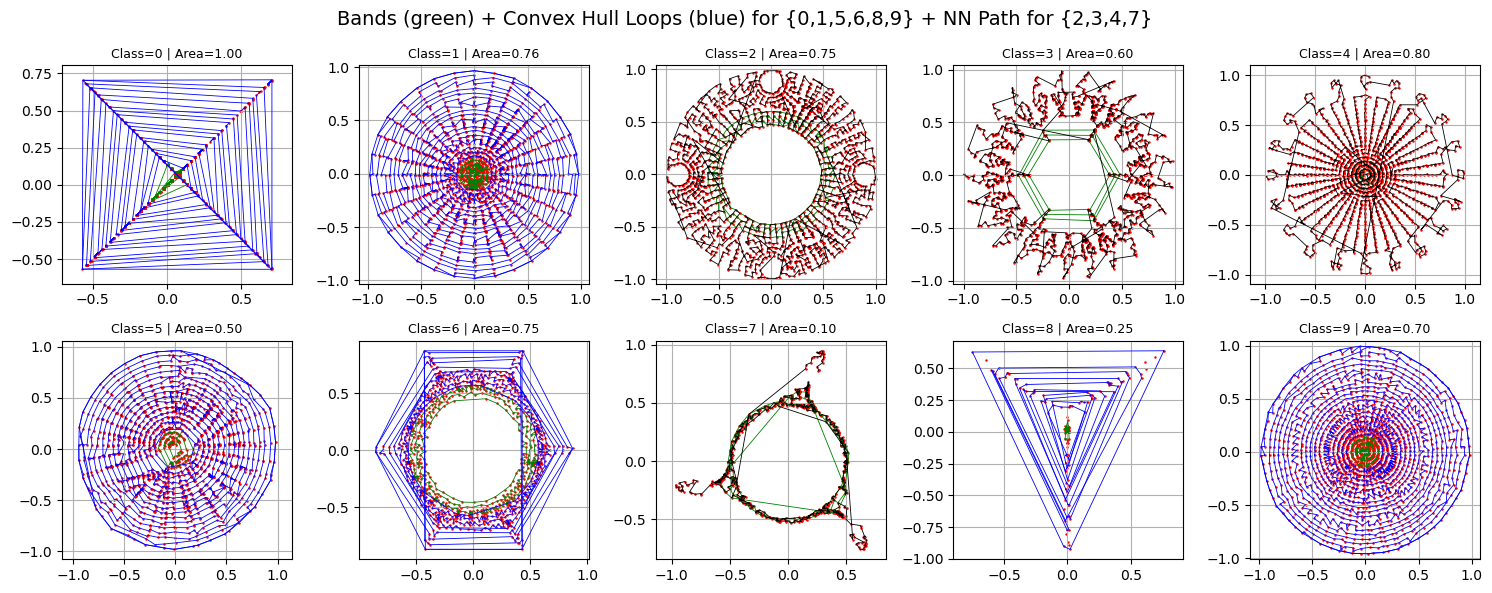

In [26]:
# =====================================================
# Inference: C-WGAN-GP (Conditional)
# Bands (green) + Convex Hull + Nested Loops (blue) for
# {0,1,5,6,8,9}, and Nearest Neighbor (blue) for {2,3,4,7}.
# =====================================================

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from scipy.spatial import ConvexHull, distance

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# =====================================================
# Paths
# =====================================================
gan_model_path = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelGANV4_WGANGP_Gauss\wgangp_gauss_generator_final.pt")
ae_model_path  = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\ModelAEV4\cae_fold5.pt")

# =====================================================
# Hyperparameters
# =====================================================
latent_size = 512
point_size = 2030
num_classes = 10
cond_dim = 1 + num_classes
device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# Models
# =====================================================
class PointCloudCAE(nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        super().__init__()
        self.P = point_size
        self.enc = nn.Sequential(
            nn.Linear(point_size * 2, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, latent_size),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_size + cond_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, point_size * 2),
        )
    def forward(self, z, cond):
        zc = torch.cat([z, cond], dim=1)
        out = self.dec(zc).view(-1, self.P, 2)
        return out

class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048), nn.LeakyReLU(0.2),
            nn.Linear(2048, latent_dim)
        )
    def forward(self, z, cond):
        return self.model(torch.cat([z, cond], dim=1))

# =====================================================
# Band Method
# =====================================================
def multilayer_bands_origin(points, band_width=0.05, max_layers=3):
    """Build multiple circular layers from origin (0,0)."""
    dists = np.sqrt(points[:,0]**2 + points[:,1]**2)
    r1 = dists.min()

    loops = []
    band_indices = set()

    for k in range(max_layers):
        low = r1 + k*band_width
        high = r1 + (k+1)*band_width

        band_mask = (dists >= low) & (dists <= high)
        band_points = points[band_mask]

        if len(band_points) > 3:
            angles = np.arctan2(band_points[:,1], band_points[:,0])
            order = np.argsort(angles)
            loop = band_points[order]
            loop = np.vstack([loop, loop[0]])
            loops.append(loop)
            band_indices.update(np.where(band_mask)[0])  # track indices

    return loops, points, band_indices, r1

# =====================================================
# Nested Loops with Convex Hull
# =====================================================
def nested_loops_with_hull(points, band_indices, r_band, step=0.05):
    """Outer convex hull, then inward shells until band."""
    dists = np.sqrt(points[:,0]**2 + points[:,1]**2)
    r_max = dists.max()

    # ignore band points
    mask = np.ones(len(points), dtype=bool)
    mask[list(band_indices)] = False
    pts = points[mask]
    dists = dists[mask]

    layers = []

    # Outermost convex hull
    if len(pts) > 3:
        try:
            hull = ConvexHull(pts)
            hull_points = pts[hull.vertices]
            hull_ordered = np.vstack([hull_points, hull_points[0]])
            layers.append(hull_ordered)
        except:
            pass

    # Inward shells
    r_current = r_max
    while r_current > r_band:
        shell_mask = (dists <= r_current) & (dists > r_current - step)
        shell_points = pts[shell_mask]

        if len(shell_points) > 3:
            angles = np.arctan2(shell_points[:,1], shell_points[:,0])
            order = np.argsort(angles)
            loop = shell_points[order]
            loop = np.vstack([loop, loop[0]])
            layers.append(loop)

        r_current -= step

    return layers

# =====================================================
# Nearest Neighbor Path
# =====================================================
def nearest_neighbor_path(points):
    """Connect all points using a simple nearest neighbor walk."""
    if len(points) < 2:
        return None

    remaining = list(range(len(points)))
    path = [remaining.pop(0)]  # start at first point

    while remaining:
        last = path[-1]
        dists = distance.cdist([points[last]], points[remaining])[0]
        nearest_idx = remaining[np.argmin(dists)]
        path.append(nearest_idx)
        remaining.remove(nearest_idx)

    loop = points[path]
    return loop

# =====================================================
# Generate One Sample per Class
# =====================================================
with torch.no_grad():
    z_noise = torch.randn(num_classes, latent_size).to(device)
    labels = torch.arange(num_classes)
    labels_onehot = F.one_hot(labels, num_classes=num_classes).float().to(device)

    #areas_list = [1, 0.76, 0.75, 0.6, 0.8, 0.5, 0.75, 0.35, 0.25, 0.7]    
    areas_list = [1, 0.76, 0.75, 0.6, 0.8, 0.5, 0.75, 0.10, 0.25, 0.7] 

    areas_dummy = torch.tensor(areas_list, dtype=torch.float32).view(num_classes, 1).to(device)

    conds = torch.cat([areas_dummy, labels_onehot], dim=1)
    fake_latents = G(z_noise, conds)
    decoded = cae(fake_latents, conds).cpu().numpy()

# =====================================================
# Plot Results
# =====================================================
rows, cols = 2, 5
fig, axs = plt.subplots(rows, cols, figsize=(15, 6))

nested_classes = {0, 1, 5, 6, 8, 9}
nn_classes = {2, 3, 4, 7}

for i in range(num_classes):
    r, c = divmod(i, cols)
    pts = np.unique(np.round(decoded[i], 6), axis=0)

    # Always apply band method
    loops, all_pts, band_indices, r_band = multilayer_bands_origin(pts, band_width=0.05, max_layers=3)
    axs[r, c].scatter(all_pts[:,0], all_pts[:,1], s=0.6, color="red")
    for loop in loops:
        axs[r, c].plot(loop[:,0], loop[:,1], '-', lw=0.6, color="green")

    # Nested + Convex Hull method
    if i in nested_classes:
        layers = nested_loops_with_hull(all_pts, band_indices, r_band, step=0.05)
        for layer in layers:
            axs[r, c].plot(layer[:,0], layer[:,1], '-', color="blue", lw=0.6)

    # Nearest Neighbor method
    if i in nn_classes:
        path = nearest_neighbor_path(all_pts)
        if path is not None:
            axs[r, c].plot(path[:,0], path[:,1], '-', color="black", lw=0.6)

    axs[r, c].set_title(f"Class={i} | Area={areas_list[i]:.2f}", fontsize=9)
    axs[r, c].axis("equal")
    axs[r, c].grid(True)

plt.suptitle("Bands (green) + Convex Hull Loops (blue) for {0,1,5,6,8,9} + NN Path for {2,3,4,7}", fontsize=14)
plt.tight_layout()
plt.show()
